<a href="https://colab.research.google.com/github/frz-indd/regresi_5C_Kelompok_3/blob/main/Kelompok3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#MACHINE LEARNING - HASIL ANALISIS DATASET MEDICAL COST PERSONAL EDA, PREPROCESSING, REGRESI

## A. Memuat Data

### Data apa yang dianalisis?
`insurance.csv` berisi data 1.338 pemegang polis asuransi kesehatan
 di Amerika Serikat. Setiap baris satu orang.

| Kolom | Jenis | Arti |
|---|---|---|
| `age` | numerik | Usia (tahun) |
| `sex` | kategorikal | Jenis kelamin (`female` / `male`) |
| `bmi` | numerik | Body Mass Index. Di atas 30 dianggap obesitas |
| `children` | numerik (diskrit) | Jumlah anak yang ditanggung |
| `smoker` | kategorikal | Perokok atau bukan (`yes` / `no`) |
| `region` | kategorikal | Wilayah tempat tinggal (4 wilayah) |
| **`charges`** | **numerik** | **Biaya medis yang ditagihkan (USD), ini yang diprediksi (target `y`)** |

Karena targetnya angka kontinu, ini masalah **regresi** (bukan klasifikasi).

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='deep')
plt.rcParams['figure.dpi'] = 100
pd.set_option('display.float_format', lambda v: f'{v:,.3f}')
pd.set_option('display.max_columns', 50)
print('Library siap dipakai')

Library siap dipakai


In [6]:
try:
    from google.colab import files
    upload = files.upload()
    nama_file = list(upload.keys())[0]
except ImportError:
    nama_file = 'insurance.csv'

df = pd.read_csv(nama_file)
print('File dibaca :', nama_file)
print('Ukuran data :', df.shape, '(baris, kolom)')
df.head(10)

Saving insurance.csv to insurance.csv
File dibaca : insurance.csv
Ukuran data : (1338, 7) (baris, kolom)


,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,"16,884.924"
1,18,male,33.770,1,no,southeast,"1,725.552"
2,28,male,33.000,3,no,southeast,"4,449.462"
3,33,male,22.705,0,no,northwest,"21,984.471"
4,32,male,28.880,0,no,northwest,"3,866.855"
5,31,female,25.740,0,no,southeast,"3,756.622"
6,46,female,33.440,1,no,southeast,"8,240.590"
7,37,female,27.740,3,no,northwest,"7,281.506"
8,37,male,29.830,2,no,northeast,"6,406.411"
9,60,female,25.840,0,no,northwest,"28,923.137"


**Hasil:** data terbaca **1.338 baris × 7 kolom**.

## B. Exploratory Data Analysis (EDA)

EDA bertujuan mengenal data sebelum memodelkan: apakah ada data kotor, bagaimana sebaran tiap variabel, dan variabel mana yang tampaknya berhubungan dengan charges.

## B.1 Struktur dan tipe data

`df.info()` menunjukkan jumlah baris, tipe data tiap kolom, dan apakah ada nilai kosong.

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


**Interpretasi:**
- Seluruh 7 kolom punya **1.338 nilai non-null**, artinya **tidak ada data kosong**.
- age, children bertipe integer; bmi, charges bertipe float; sex, smoker, region bertipe teks (kategorikal).
- Tiga kolom teks **harus diubah menjadi angka** (encoding) sebelum masuk ke model regresi. Ini dikerjakan di bagian C.

## B.2 Statistik deskriptif

`describe()` meringkas rata-rata, sebaran (std), nilai minimum/maksimum, dan kuartil.

In [8]:
print('=== Statistik kolom numerik ===')
display(df.describe().T)
print('\n=== Statistik kolom kategorikal ===')
display(df.describe(include='object').T)

=== Statistik kolom numerik ===


,count,mean,std,min,25%,50%,75%,max
age,"1,338.000",39.207,14.050,18.000,27.000,39.000,51.000,64.000
bmi,"1,338.000",30.663,6.098,15.960,26.296,30.400,34.694,53.130
children,"1,338.000",1.095,1.205,0.000,0.000,1.000,2.000,5.000
charges,"1,338.000","13,270.422","12,110.011","1,121.874","4,740.287","9,382.033","16,639.913","63,770.428"



=== Statistik kolom kategorikal ===


,count,unique,top,freq
sex,1338,2,male,676
smoker,1338,2,no,1064
region,1338,4,southeast,364


**Interpretasi:**
- **Usia** 18 sampai 64 tahun, rata-rata ±39 tahun (median 39), jadi sebarannya cukup merata.
- **BMI** rata-rata ±30,66, **tepat di batas obesitas (30)**. Artinya lebih dari separuh peserta tergolong obesitas. Rentang 15,96 sampai 53,13.
- **Anak** 0 sampai 5, rata-rata ±1,1.
- **Charges** rata-rata ±13.270 tetapi **median hanya ±9.382**, dan maksimum 63.770. Rata-rata jauh di atas median berarti distribusi **menceng ke kanan**: sebagian kecil orang menanggung biaya sangat besar.
- Kolom kategorikal: `male` (676) dan `female` (662) seimbang, `smoker=no` mendominasi, dan `region` terbagi hampir rata (southeast paling banyak, 364).

## B.3 Kualitas data: missing value dan duplikat

In [9]:
print('Missing value per kolom:')
print(df.isna().sum())
print('\nJumlah baris duplikat :', df.duplicated().sum())
print('\nBaris yang duplikat:')
display(df[df.duplicated(keep=False)])

Missing value per kolom:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Jumlah baris duplikat : 1

Baris yang duplikat:


,age,sex,bmi,children,smoker,region,charges
195,19,male,30.590,0,no,northwest,"1,639.563"
581,19,male,30.590,0,no,northwest,"1,639.563"


**Interpretasi:**
- **Tidak ada missing value** di semua kolom, jadi tidak perlu imputasi.
- Ada **1 baris duplikat** (baris 195 dan 581: laki-laki 19 tahun, bmi 30,59, non-perokok, northwest, charges 1.639,56). Duplikat bisa membuat satu observasi terhitung dua kali, termasuk bocor antara data latih dan uji, jadi dihapus di bagian C.

## B.4 Distribusi variabel numerik (univariat)

Histogram menunjukkan bentuk sebaran. Garis merah = rata-rata, garis hijau = median. **Skewness** mengukur kemencengan: 0 = simetris, positif = ekor panjang di kanan.

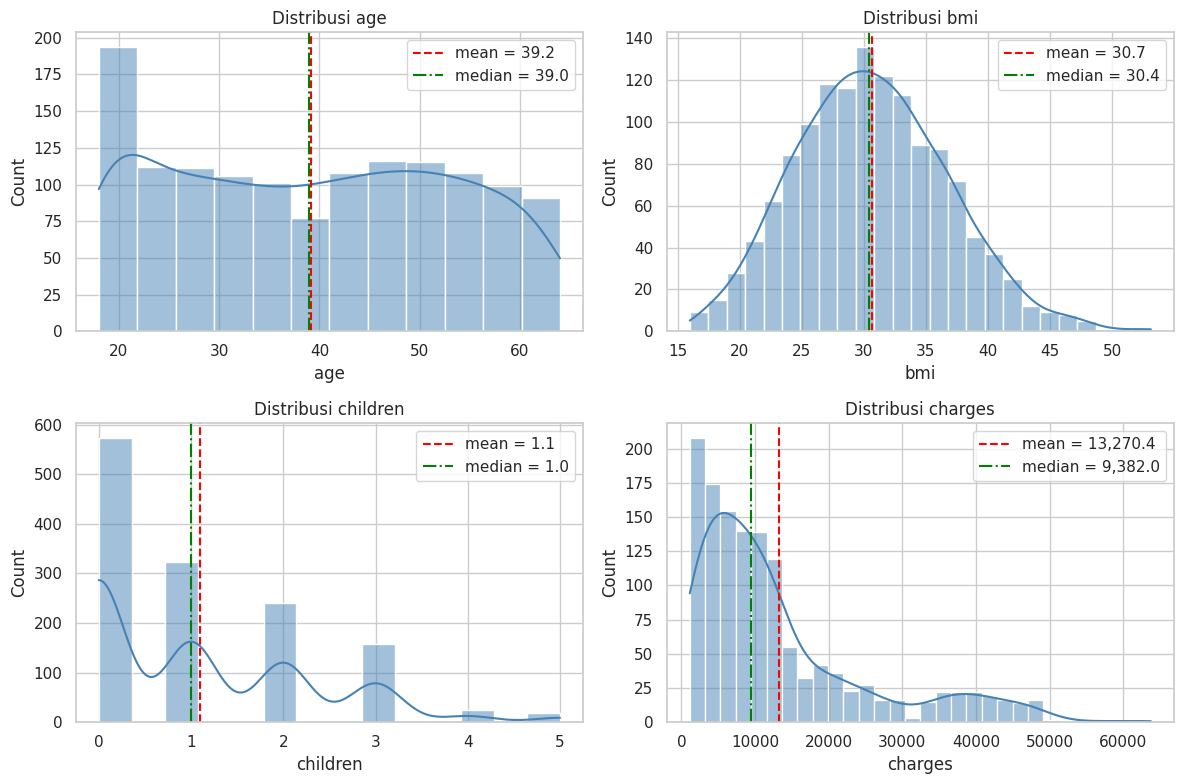

Skewness (kemencengan) tiap variabel numerik:
age        0.056
bmi        0.284
children   0.938
charges    1.516
dtype: float64


In [10]:
kolom_num = ['age', 'bmi', 'children', 'charges']
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, k in zip(axes.ravel(), kolom_num):
    sns.histplot(df[k], kde=True, ax=ax, color='steelblue')
    ax.axvline(df[k].mean(), color='red', ls='--', label=f'mean = {df[k].mean():,.1f}')
    ax.axvline(df[k].median(), color='green', ls='-.', label=f'median = {df[k].median():,.1f}')
    ax.set_title(f'Distribusi {k}')
    ax.legend()
plt.tight_layout()
plt.show()

print('Skewness (kemencengan) tiap variabel numerik:')
print(df[kolom_num].skew())

**Interpretasi:**

| Variabel | Skewness | Bentuk distribusi |
|---|---|---|
| `age` | 0,056 | Hampir simetris, cukup merata dari 18 sampai 64 |
| `bmi` | 0,284 | Mendekati lonceng (normal), sedikit ekor kanan |
| `children` | 0,938 | Menceng kanan: kebanyakan 0 sampai 2 anak |
| `charges` | **1,516** | **Menceng kanan kuat**: banyak biaya kecil, sedikit biaya sangat besar |

Distribusi `charges` yang menceng membuat **rata-rata terseret ke atas** (mean 13.270 vs median 9.382). Ini memengaruhi asumsi regresi linear (residual idealnya simetris), dan akan kita bahas lagi di bagian D dan E.

## B.7 Hubungan variabel kategorikal dengan `charges` (bivariat)

Boxplot membandingkan sebaran biaya antar kategori. Tabel di bawahnya memberi angka pastinya.

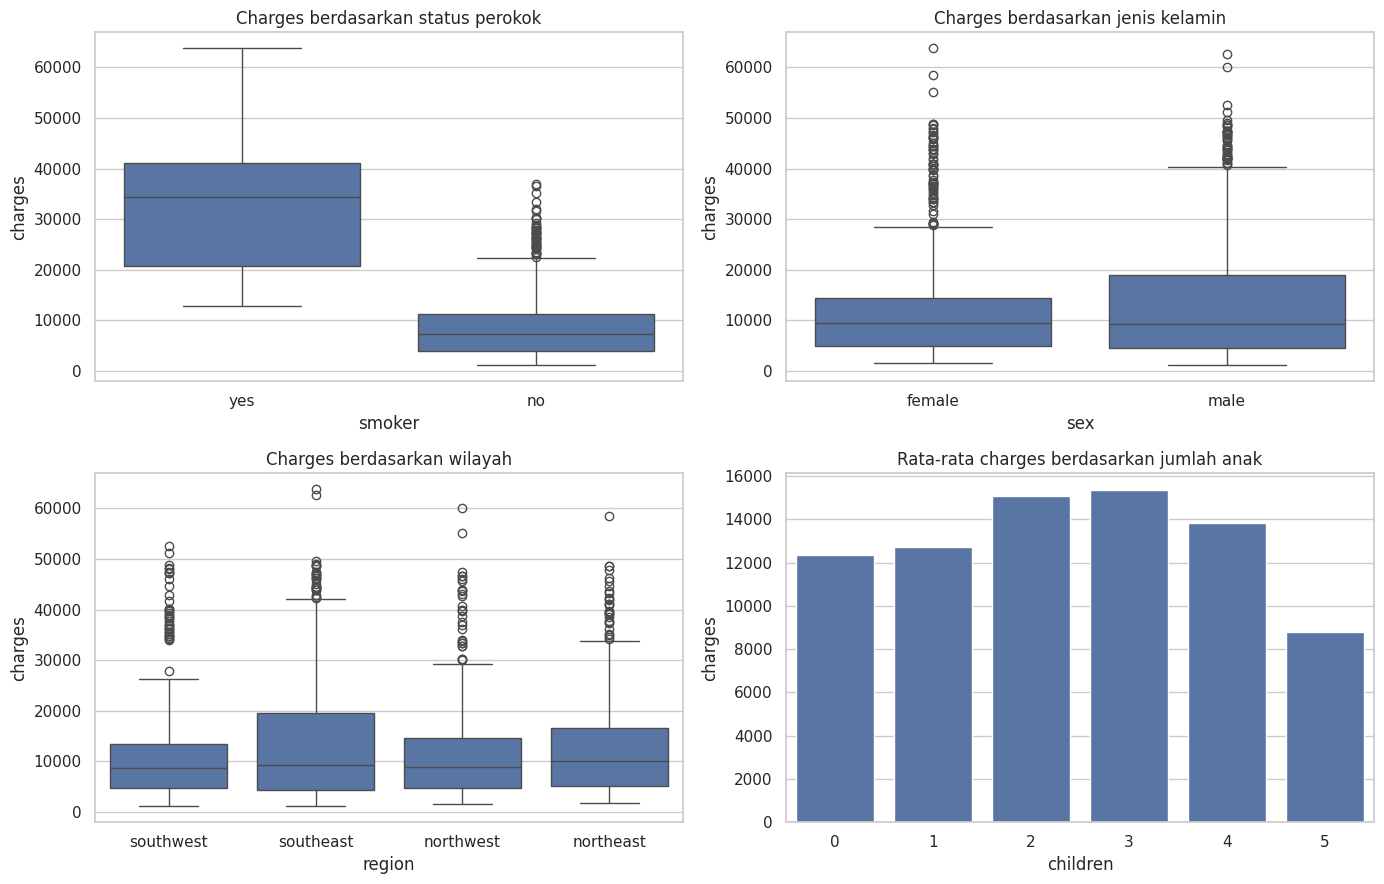

Rata-rata & median charges per kategori:

--- smoker ---


,count,mean,median,std
smoker,,,,
no,1064,"8,434.268","7,345.405","5,993.782"
yes,274,"32,050.232","34,456.348","11,541.547"



--- sex ---


,count,mean,median,std
sex,,,,
female,662,"12,569.579","9,412.962","11,128.704"
male,676,"13,956.751","9,369.616","12,971.026"



--- region ---


,count,mean,median,std
region,,,,
northeast,324,"13,406.385","10,057.652","11,255.803"
northwest,325,"12,417.575","8,965.796","11,072.277"
southeast,364,"14,735.411","9,294.132","13,971.099"
southwest,325,"12,346.937","8,798.593","11,557.179"



--- children ---


,count,mean,median,std
children,,,,
0,574,"12,365.976","9,856.952","12,023.294"
1,324,"12,731.172","8,483.870","11,823.631"
2,240,"15,073.564","9,264.979","12,891.368"
3,157,"15,355.318","10,600.548","12,330.869"
4,25,"13,850.656","11,033.662","9,139.223"
5,18,"8,786.035","8,589.565","3,808.436"


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))
sns.boxplot(data=df, x='smoker', y='charges', ax=axes[0, 0])
axes[0, 0].set_title('Charges berdasarkan status perokok')
sns.boxplot(data=df, x='sex', y='charges', ax=axes[0, 1])
axes[0, 1].set_title('Charges berdasarkan jenis kelamin')
sns.boxplot(data=df, x='region', y='charges', ax=axes[1, 0])
axes[1, 0].set_title('Charges berdasarkan wilayah')
sns.barplot(data=df, x='children', y='charges', ax=axes[1, 1], errorbar=None)
axes[1, 1].set_title('Rata-rata charges berdasarkan jumlah anak')
plt.tight_layout()
plt.show()

print('Rata-rata & median charges per kategori:')
for k in ['smoker', 'sex', 'region', 'children']:
    print(f'\n--- {k} ---')
    display(df.groupby(k)['charges'].agg(['count', 'mean', 'median', 'std']))

**Interpretasi:**

| Faktor | Temuan |
|---|---|
| **`smoker`** | **Perbedaan sangat besar.** Perokok rata-rata **32.050** vs non-perokok **8.434**, sekitar **3,8 kali lipat**. Hampir tidak ada tumpang tindih antara kotak kedua kelompok. |
| `sex` | Laki-laki rata-rata 13.957, perempuan 12.570, **tetapi median hampir sama** (±9.400). Selisih rata-rata kemungkinan karena beberapa kasus mahal, bukan perbedaan sistematis. |
| `region` | Southeast tertinggi (14.735), southwest terendah (12.347). Perbedaan kecil dan sebarannya tumpang tindih. |
| `children` | Rata-rata naik dari 0 ke 3 anak (12.366 → 15.355) lalu turun di 5 anak (8.786, hanya 18 orang). Pola **tidak monoton**, pengaruhnya lemah. |

**Kesimpulan sementara:** `smoker` adalah faktor dominan. `sex`, `region`, dan `children` tampak berpengaruh kecil.

## B.8 Hubungan variabel numerik dengan `charges` (scatter plot)

Scatter plot dipakai untuk melihat pola hubungan. Warna membedakan perokok dan non-perokok, dan panel ketiga membedakan obesitas (BMI ≥ 30).

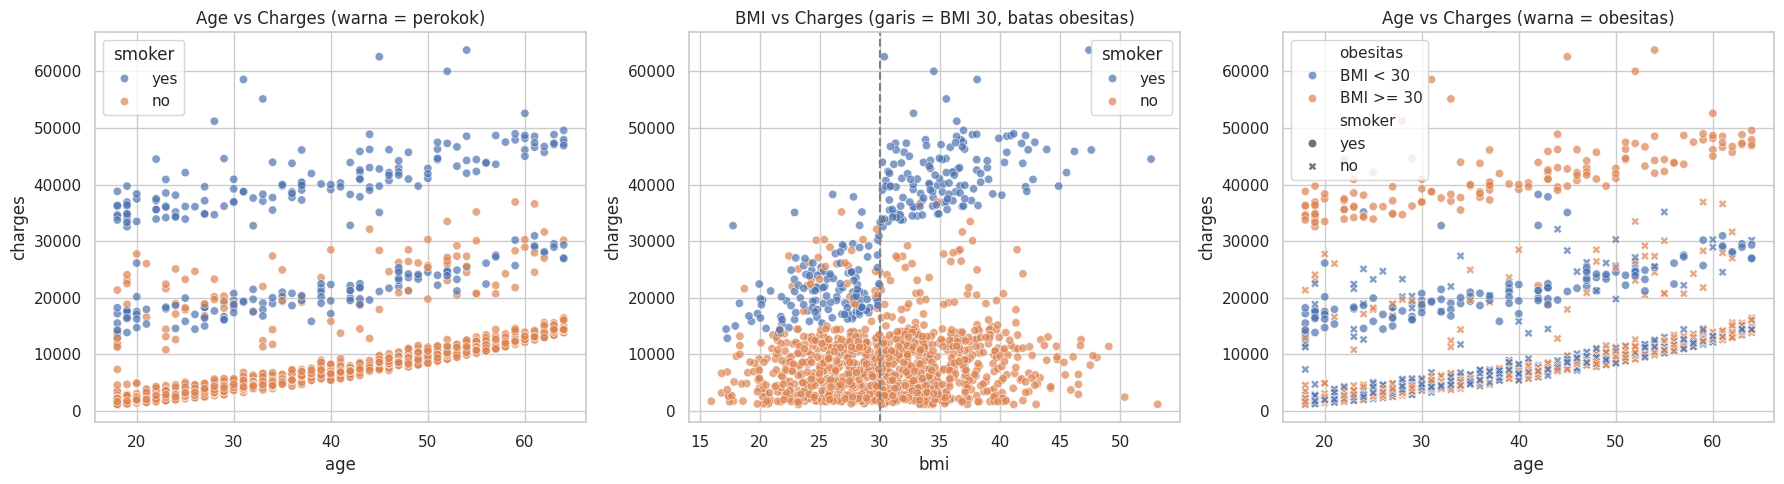

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
sns.scatterplot(data=df, x='age', y='charges', hue='smoker', alpha=0.7, ax=axes[0])
axes[0].set_title('Age vs Charges (warna = perokok)')
sns.scatterplot(data=df, x='bmi', y='charges', hue='smoker', alpha=0.7, ax=axes[1])
axes[1].axvline(30, color='gray', ls='--')
axes[1].set_title('BMI vs Charges (garis = BMI 30, batas obesitas)')
d_ob = df.assign(obesitas=np.where(df['bmi'] >= 30, 'BMI >= 30', 'BMI < 30'))
sns.scatterplot(data=d_ob, x='age', y='charges', hue='obesitas', style='smoker', alpha=0.7, ax=axes[2])
axes[2].set_title('Age vs Charges (warna = obesitas)')
plt.tight_layout()
plt.show()

**Interpretasi:**
- **Age vs Charges (panel kiri):** biaya naik seiring usia (tren positif). Titik **terpisah menjadi tiga pita**: pita paling bawah hampir seluruhnya non-perokok (garis rapi dari ±2.000 sampai ±15.000), pita tengah (±15.000 sampai ±30.000) berisi perokok dan sebagian kecil non-perokok, dan pita atas (±35.000 sampai ±50.000) seluruhnya perokok. Usia menaikkan biaya di semua pita, tetapi **posisi pita ditentukan oleh status merokok**.
- **BMI vs Charges (panel tengah):** untuk non-perokok (oranye), biaya **tidak bergantung pada BMI** (sebaran datar). Untuk perokok (biru), biaya **melonjak tajam saat BMI melewati 30** (dari ±20.000-30.000 menjadi ±35.000-50.000). Ini ciri **interaksi**: efek BMI baru muncul bila orang itu merokok.
- **Panel kanan:** pita atas hampir seluruhnya berwarna obesitas (BMI ≥ 30) dan berbentuk lingkaran (perokok). Pita tengah didominasi perokok BMI < 30. Jadi tiga pita itu = non-perokok, perokok tidak obesitas, perokok obesitas.

Pola ini penting: model linear sederhana (hanya menjumlahkan efek) **tidak bisa menangkap interaksi** ini. Kita akan menambah fitur interaksi di bagian E.

## B.9 Interaksi perokok × obesitas

Untuk membuktikan dugaan interaksi tadi, kita hitung rata-rata biaya pada empat kombinasi (perokok/bukan × obesitas/tidak).

count                              mean               
obesitas Obesitas (BMI>=30) Tidak obesitas Obesitas (BMI>=30) Tidak obesitas
smoker                                                                      
no                      562            502          8,842.692      7,977.030
yes                     145            129         41,557.990     21,363.217

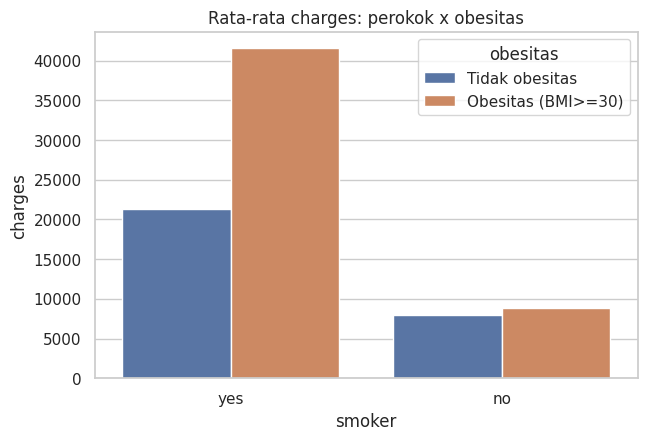

In [13]:
df_eda = df.copy()
df_eda['obesitas'] = np.where(df_eda['bmi'] >= 30, 'Obesitas (BMI>=30)', 'Tidak obesitas')
tabel = df_eda.pivot_table(index='smoker', columns='obesitas', values='charges',
                           aggfunc=['count', 'mean'])
display(tabel)

plt.figure(figsize=(7, 4.5))
sns.barplot(data=df_eda, x='smoker', y='charges', hue='obesitas', errorbar=None)
plt.title('Rata-rata charges: perokok x obesitas')
plt.show()

**Interpretasi:**

| | Tidak obesitas | Obesitas (BMI ≥ 30) |
|---|---|---|
| **Bukan perokok** | 7.977 (502 orang) | 8.843 (562 orang) |
| **Perokok** | 21.363 (129 orang) | **41.558** (145 orang) |

- Pada **non-perokok**, obesitas hanya menaikkan biaya sekitar **11%** (7.977 → 8.843).
- Pada **perokok**, obesitas menaikkan biaya sekitar **95%** (21.363 → 41.558), hampir dua kali lipat.

Jadi pengaruh obesitas **berlipat ganda hanya pada perokok**. Ini bukti kuat adanya **efek interaksi** yang perlu dimodelkan.

## B.10 Korelasi antar variabel

Matriks korelasi Pearson mengukur kekuatan hubungan **linear** (−1 sampai +1). Kolom `sex` dan `smoker` diubah ke 0/1 dulu agar bisa dihitung.

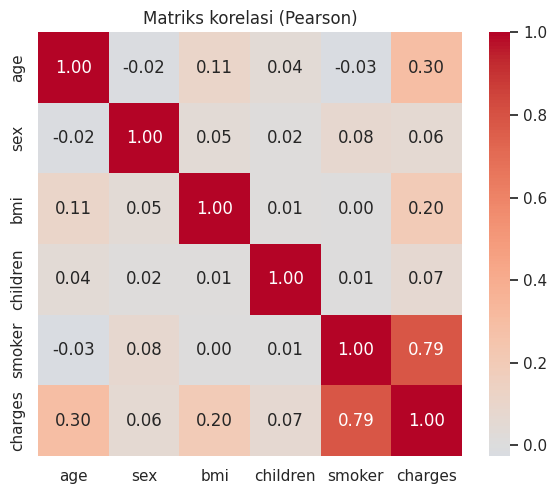

Korelasi tiap fitur terhadap charges (diurutkan):
smoker     0.787
age        0.299
bmi        0.198
children   0.068
sex        0.057
Name: charges, dtype: float64


In [14]:
df_corr = df.copy()
df_corr['sex'] = df_corr['sex'].map({'female': 0, 'male': 1})
df_corr['smoker'] = df_corr['smoker'].map({'no': 0, 'yes': 1})
korelasi = df_corr.drop(columns='region').corr()

plt.figure(figsize=(7, 5.5))
sns.heatmap(korelasi, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('Matriks korelasi (Pearson)')
plt.show()

print('Korelasi tiap fitur terhadap charges (diurutkan):')
print(korelasi['charges'].drop('charges').sort_values(ascending=False))

**Interpretasi korelasi dengan `charges`:**

| Fitur | Korelasi | Makna |
|---|---|---|
| `smoker` | **0,787** | **Sangat kuat**, fitur terpenting |
| `age` | 0,299 | Lemah-sedang |
| `bmi` | 0,198 | Lemah (karena efeknya hanya pada perokok) |
| `children` | 0,068 | Sangat lemah |
| `sex` | 0,057 | Hampir tidak ada |

Korelasi antar-fitur independen juga rendah, jadi **tidak ada multikolinearitas yang mengkhawatirkan** (dikonfirmasi lagi lewat VIF di bagian D). Catatan: korelasi hanya mengukur hubungan linear, sehingga `bmi` tampak lemah padahal punya efek lewat interaksi dengan `smoker`.

## C. Preprocessing

Tahap ini mengubah data mentah menjadi format yang bisa diterima model. **Urutannya penting**:

`hapus duplikat → encoding → split latih/uji → scaling (fit hanya dari data latih)`

Alasan "split dulu baru scaling": jika scaling dilakukan sebelum split, statistik data uji ikut terhitung dan terjadi data leakage.

## C.1 Menghapus data duplikat

In [15]:
print('Ukuran sebelum hapus duplikat :', df.shape)
df_clean = df.drop_duplicates().reset_index(drop=True)
print('Ukuran sesudah hapus duplikat :', df_clean.shape)
print('Missing value total           :', df_clean.isna().sum().sum())

Ukuran sebelum hapus duplikat : (1338, 7)
Ukuran sesudah hapus duplikat : (1337, 7)
Missing value total           : 0


**Hasil:** data berkurang dari 1.338 menjadi **1.337 baris** (1 duplikat dibuang), dan tidak ada missing value sehingga **tidak perlu imputasi**.

## C.2 Encoding variabel kategorikal

Model regresi hanya menerima angka, jadi teks harus diubah:
- **`sex`** dan **`smoker`** hanya punya 2 kategori, maka dipakai **label encoding 0/1** (`female=0, male=1`, `no=0, yes=1`).
- **`region`** punya 4 kategori tanpa urutan, maka dipakai **one-hot encoding**. Memberi angka 0 sampai 3 akan menyiratkan urutan yang tidak ada.
- `drop_first=True` membuang satu kolom dummy (northeast jadi **kategori acuan**). Tanpa itu, keempat dummy selalu berjumlah 1 dan berkolinearitas sempurna dengan intercept (*dummy variable trap*), sehingga koefisien tidak bisa diinterpretasikan dengan jelas.

In [16]:
df_enc = df_clean.copy()

# 1) Biner -> label encoding 0/1
df_enc['sex'] = df_enc['sex'].map({'female': 0, 'male': 1})
df_enc['smoker'] = df_enc['smoker'].map({'no': 0, 'yes': 1})

# 2) Nominal multi-kategori -> one-hot encoding (drop_first menghindari dummy variable trap)
df_enc = pd.get_dummies(df_enc, columns=['region'], drop_first=True, dtype=int)

print('Kolom setelah encoding:', list(df_enc.columns))
df_enc.head()

Kolom setelah encoding: ['age', 'sex', 'bmi', 'children', 'smoker', 'charges', 'region_northwest', 'region_southeast', 'region_southwest']


,age,sex,bmi,children,smoker,charges,region_northwest,region_southeast,region_southwest
0,19,0,27.900,0,1,"16,884.924",0,0,1
1,18,1,33.770,1,0,"1,725.552",0,1,0
2,28,1,33.000,3,0,"4,449.462",0,1,0
3,33,1,22.705,0,0,"21,984.471",1,0,0
4,32,1,28.880,0,0,"3,866.855",1,0,0


**Hasil:** kolom `region` berganti menjadi 3 kolom biner: `region_northwest`, `region_southeast`, `region_southwest`. Baris dengan ketiganya bernilai 0 berarti **northeast**. Contohnya baris 3 (northwest) punya `region_northwest = 1`.

## C.3 Memisahkan fitur (X) dan target (y), lalu split data latih/uji

- `X` = semua kolom kecuali `charges`; `y` = `charges`.
- Pembagian **80% latih / 20% uji** (sesuai modul), `random_state=42` agar hasil bisa diulang.
- `stratify=smoker` menjaga proporsi perokok sama di data latih dan uji, penting karena perokok hanya ±20% dan merupakan faktor paling berpengaruh.

In [17]:
from sklearn.model_selection import train_test_split

X = df_enc.drop(columns=['charges'])
y = df_enc['charges']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=df_enc['smoker']
)

print('X_train:', X_train.shape, '| X_test:', X_test.shape)
print('\nProporsi perokok -> train: {:.3f} | test: {:.3f}'.format(
    X_train['smoker'].mean(), X_test['smoker'].mean()))
print('Rata-rata charges -> train: {:,.0f} | test: {:,.0f}'.format(y_train.mean(), y_test.mean()))

X_train: (1069, 8) | X_test: (268, 8)

Proporsi perokok -> train: 0.205 | test: 0.205
Rata-rata charges -> train: 13,356 | test: 12,973


**Hasil:** 1.069 baris latih dan 268 baris uji. Proporsi perokok **identik (20,5%)** di kedua set, membuktikan stratifikasi bekerja. Rata-rata charges latih 13.356 vs uji 12.973, tidak jauh berbeda.

## C.4 Scaling (standardisasi)

`StandardScaler` mengubah fitur numerik menjadi rata-rata 0 dan simpangan baku 1: `z = (x − mean) / std`.
- Hanya `age`, `bmi`, `children` yang di-scale. Kolom biner 0/1 dibiarkan.
- **`fit_transform` pada data latih, `transform` saja pada data uji**, agar data uji memakai parameter (mean, std) dari data latih.

In [18]:
from sklearn.preprocessing import StandardScaler

num = ['age', 'bmi', 'children']
sc = StandardScaler()

X_train_sc = X_train.copy()
X_test_sc = X_test.copy()
X_train_sc[num] = sc.fit_transform(X_train[num])   # fit HANYA dari data latih
X_test_sc[num] = sc.transform(X_test[num])         # data uji hanya transform

print('Rata-rata & std data latih setelah scaling:')
display(X_train_sc[num].agg(['mean', 'std']))
print('Rata-rata & std data uji setelah scaling (tidak harus 0 dan 1):')
display(X_test_sc[num].agg(['mean', 'std']))
print('Parameter yang dipelajari scaler dari data latih:')
print(pd.DataFrame({'mean': sc.mean_, 'std': np.sqrt(sc.var_)}, index=num))

Rata-rata & std data latih setelah scaling:


,age,bmi,children
mean,-0.000,-0.000,-0.000
std,1.000,1.000,1.000


Rata-rata & std data uji setelah scaling (tidak harus 0 dan 1):


,age,bmi,children
mean,0.057,-0.132,0.021
std,0.999,1.007,1.098


Parameter yang dipelajari scaler dari data latih:
           mean    std
age      39.063 14.044
bmi      30.824  6.083
children  1.091  1.181


**Interpretasi:**
- Pada data latih, mean semua fitur **0,000** dan std **1,000** (sesuai rumus).
- Pada data uji mean dan std **tidak persis 0 dan 1** (misalnya mean `bmi` −0,132). **Ini benar dan wajar**: tandanya scaler hanya belajar dari data latih, sehingga tidak ada kebocoran.
- Parameter yang dipelajari: mean usia 39,06 (std 14,04); mean bmi 30,82 (std 6,08).

> **Catatan:** untuk Regresi Linear biasa (OLS), scaling **tidak mengubah prediksi atau metrik**, hanya mengubah skala koefisien. Ini dibuktikan di D.2. Scaling tetap penting untuk Ridge/Lasso (E.3) karena penalti bergantung pada besar koefisien.

## D. Regresi Linear (Baseline)

Persamaan model (dari PPT Pertemuan 5):

$$\text{charges} = b_0 + b_1\,\text{age} + b_2\,\text{sex} + b_3\,\text{bmi} + b_4\,\text{children} + b_5\,\text{smoker} + b_6\,\text{region}_{nw} + b_7\,\text{region}_{se} + b_8\,\text{region}_{sw}$$

Model belajar dengan meminimalkan **MSE** (rata-rata kuadrat galat). Pola kerja scikit-learn: **fit → predict → evaluate**.

## D.1 Melatih model dan membaca koefisien

Model dilatih pada skala **asli** (belum di-scale) supaya koefisien bisa dibaca langsung dalam dolar.

In [19]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Model baseline pada skala ASLI agar koefisien mudah dibaca dalam satuan dolar
model = LinearRegression()
model.fit(X_train, y_train)

print('Intercept (b0):', round(model.intercept_, 2))
koef = pd.DataFrame({'fitur': X.columns, 'koefisien': model.coef_}).sort_values('koefisien', key=abs, ascending=False)
display(koef.reset_index(drop=True))

Intercept (b0): -11593.79


,fitur,koefisien
0,smoker,"23,750.032"
1,region_southeast,"-1,193.734"
2,region_southwest,"-1,031.822"
3,children,626.134
4,region_northwest,-361.197
5,bmi,330.832
6,sex,-257.961
7,age,255.925


**Persamaan hasil:** `charges = −11.594 + 255,9·age − 258,0·sex + 330,8·bmi + 626,1·children + 23.750·smoker − 361,2·region_nw − 1.193,7·region_se − 1.031,8·region_sw`

**Interpretasi (dengan asumsi fitur lain tetap):**

| Koefisien | Arti |
|---|---|
| **Intercept −11.594** | Nilai prediksi bila semua fitur 0 (usia 0, BMI 0, dst.). Tidak punya makna nyata karena usia 0 dan BMI 0 tidak mungkin; hanya titik awal garis. |
| **`smoker` +23.750** | Perokok diprediksi membayar **±23.750 USD lebih mahal** daripada non-perokok. Pengaruh terbesar. |
| `age` +255,9 | Tiap bertambah **1 tahun**, biaya naik ±256 USD. |
| `bmi` +330,8 | Tiap naik **1 poin BMI**, biaya naik ±331 USD. |
| `children` +626,1 | Tiap tambahan **1 anak**, biaya naik ±626 USD. |
| `sex` −258,0 | Laki-laki ±258 USD lebih murah daripada perempuan (**tidak signifikan**, lihat D.5). |
| `region_southeast` −1.193,7 | Dibanding northeast (acuan), southeast ±1.194 lebih murah. |
| `region_southwest` −1.031,8 | Dibanding northeast, ±1.032 lebih murah. |
| `region_northwest` −361,2 | Dibanding northeast, ±361 lebih murah (**tidak signifikan**). |

**Koefisien dummy region** selalu dibaca **relatif terhadap kategori acuan (northeast)**.

## D.2 Evaluasi model

Evaluasi dilakukan pada **data uji** (data yang tidak dipakai saat melatih):
- **MSE**: rata-rata kuadrat galat (satuan USD²). Makin kecil makin baik.
- **RMSE**: akar MSE, kembali ke satuan USD, yaitu rata-rata besar kesalahan prediksi.
- **MAE**: rata-rata galat absolut, tidak terlalu terpengaruh kasus ekstrem.
- **R²**: proporsi variasi `charges` yang dijelaskan model (0 sampai 1).

Kita juga membandingkan R² data latih vs uji untuk mendeteksi *overfitting*.

In [20]:
def evaluasi(model, Xtr, ytr, Xte, yte, nama='Model'):
    p_tr, p_te = model.predict(Xtr), model.predict(Xte)
    return {
        'Model': nama,
        'R2 train': r2_score(ytr, p_tr),
        'R2 test': r2_score(yte, p_te),
        'MSE test': mean_squared_error(yte, p_te),
        'RMSE test': np.sqrt(mean_squared_error(yte, p_te)),
        'MAE test': mean_absolute_error(yte, p_te),
    }

hasil_baseline = evaluasi(model, X_train, y_train, X_test, y_test, 'Linear Regression (baseline)')
display(pd.DataFrame([hasil_baseline]).set_index('Model').T)

y_pred = model.predict(X_test)
print(f"Rata-rata charges data uji : {y_test.mean():,.0f}")
print(f"RMSE sebagai % dari rata-rata: {hasil_baseline['RMSE test'] / y_test.mean() * 100:.1f}%")

Model,Linear Regression (baseline)
R2 train,0.733
R2 test,0.820
MSE test,"25,876,347.321"
RMSE test,"5,086.880"
MAE test,"3,592.793"


Rata-rata charges data uji : 12,973
RMSE sebagai % dari rata-rata: 39.2%


**Interpretasi:**

| Metrik | Nilai | Makna |
|---|---|---|
| R² test | **0,820** | Model menjelaskan **±82%** variasi biaya pada data uji |
| R² train | 0,733 | Lebih rendah dari test |
| RMSE test | **±5.087 USD** | Prediksi rata-rata meleset ±5.087 USD |
| MAE test | ±3.593 USD | Rata-rata galat absolut |
| RMSE / rata-rata | 39,2% | Galat masih besar dibanding rata-rata biaya (12.973) |

- **Tidak overfitting**: R² test (0,820) justru **lebih tinggi** dari R² train (0,733). Ini bukan tanda model sempurna, kemungkinan karena data uji kebetulan "lebih mudah". Buktinya terlihat di cross-validation (D.4): rata-rata R² hanya ±0,74. **Jadi satu kali split cenderung terlalu optimis.**
- R² 0,82 terlihat bagus, tetapi RMSE ±39% dari rata-rata biaya menunjukkan **prediksi per individu masih kasar**.

R2 test (skala asli)   : 0.820497
R2 test (setelah scale): 0.820497


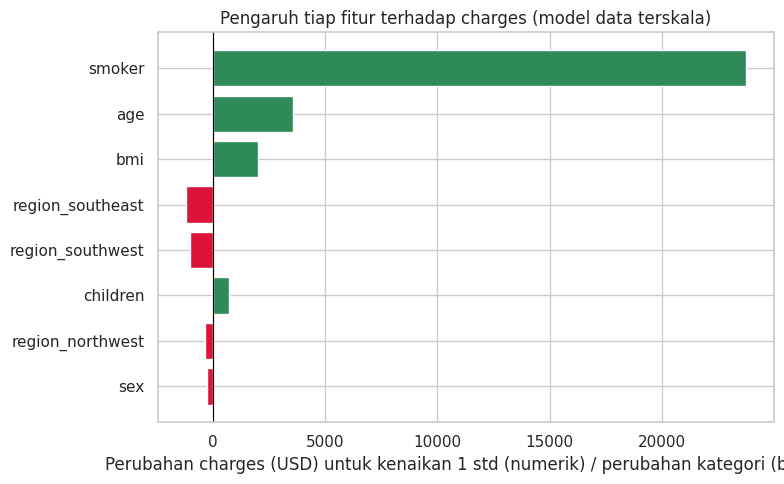

In [21]:
# Apakah scaling mengubah hasil Linear Regression? Cek langsung.
model_sc = LinearRegression().fit(X_train_sc, y_train)
print('R2 test (skala asli)   :', round(r2_score(y_test, model.predict(X_test)), 6))
print('R2 test (setelah scale):', round(r2_score(y_test, model_sc.predict(X_test_sc)), 6))

# Koefisien terstandarisasi -> bisa dibandingkan antar fitur numerik
std_koef = pd.DataFrame({'fitur': X.columns, 'koef_terstandarisasi': model_sc.coef_})
std_koef = std_koef.sort_values('koef_terstandarisasi', key=abs, ascending=True)

plt.figure(figsize=(8, 5))
warna = ['crimson' if v < 0 else 'seagreen' for v in std_koef['koef_terstandarisasi']]
plt.barh(std_koef['fitur'], std_koef['koef_terstandarisasi'], color=warna)
plt.axvline(0, color='black', lw=0.8)
plt.xlabel('Perubahan charges (USD) untuk kenaikan 1 std (numerik) / perubahan kategori (biner)')
plt.title('Pengaruh tiap fitur terhadap charges (model data terskala)')
plt.tight_layout()
plt.show()

**Interpretasi:**
- R² test sebelum dan sesudah scaling **identik (0,820497)**, membuktikan scaling tidak memengaruhi prediksi Regresi Linear biasa.
- Grafik menampilkan **koefisien terstandarisasi**, sehingga fitur numerik bisa dibandingkan adil (satuannya "per 1 simpangan baku"). Urutan pengaruh: **`smoker` (±23.750) jauh di atas** `age` (±3.600 per 1 std) dan `bmi` (±2.000 per 1 std), disusul `region_southeast` dan `region_southwest` (negatif, ±1.000 sampai 1.200), `children` (±740 per 1 std), lalu `region_northwest` dan `sex` yang kecil.
- Dengan kata lain, **status merokok lebih berpengaruh daripada usia, BMI, dan jumlah anak digabung**.

## D.3 Analisis residual

Residual = nilai aktual − prediksi. Model yang baik punya residual yang **acak di sekitar nol, tanpa pola**, dan berdistribusi mendekati normal. Empat grafik: (a) aktual vs prediksi, (b) residual vs prediksi (Langkah 5 modul), (c) histogram residual, (d) Q-Q plot.

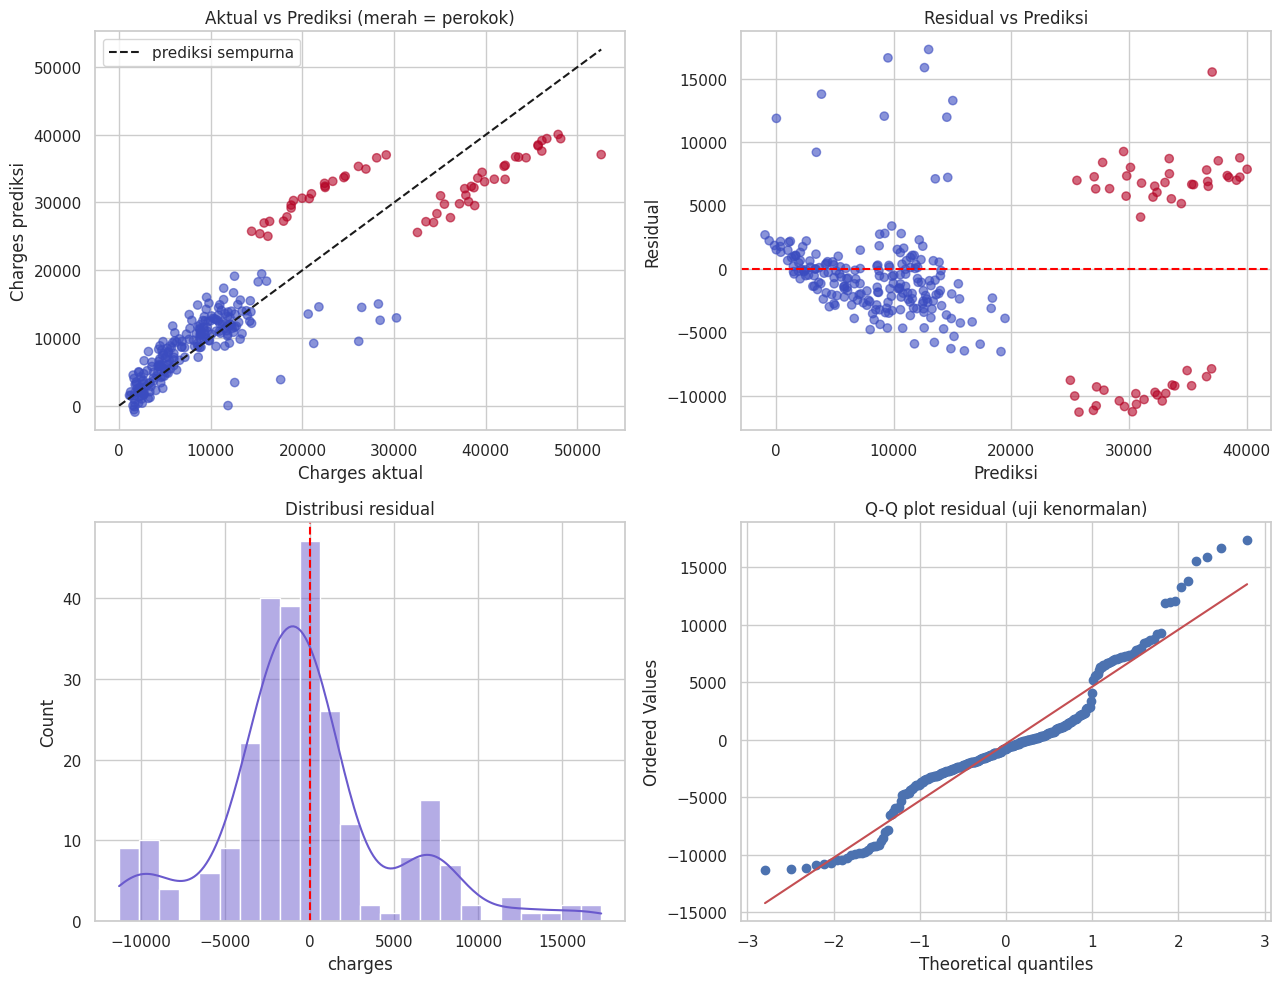

Rata-rata residual : -345.3
Skewness residual  : 0.62


In [22]:
residual = y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (a) Aktual vs prediksi
axes[0, 0].scatter(y_test, y_pred, alpha=0.6, c=X_test['smoker'], cmap='coolwarm')
lim = [0, max(y_test.max(), y_pred.max())]
axes[0, 0].plot(lim, lim, 'k--', label='prediksi sempurna')
axes[0, 0].set_xlabel('Charges aktual'); axes[0, 0].set_ylabel('Charges prediksi')
axes[0, 0].set_title('Aktual vs Prediksi (merah = perokok)'); axes[0, 0].legend()

# (b) Residual vs prediksi (sesuai Langkah 5 modul)
axes[0, 1].scatter(y_pred, residual, alpha=0.6, c=X_test['smoker'], cmap='coolwarm')
axes[0, 1].axhline(0, color='red', ls='--')
axes[0, 1].set_xlabel('Prediksi'); axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residual vs Prediksi')

# (c) Histogram residual
sns.histplot(residual, kde=True, ax=axes[1, 0], color='slateblue')
axes[1, 0].axvline(0, color='red', ls='--')
axes[1, 0].set_title('Distribusi residual')

# (d) Q-Q plot
from scipy import stats
stats.probplot(residual, dist='norm', plot=axes[1, 1])
axes[1, 1].set_title('Q-Q plot residual (uji kenormalan)')

plt.tight_layout()
plt.show()

print(f'Rata-rata residual : {residual.mean():,.1f}')
print(f'Skewness residual  : {residual.skew():.2f}')

**Interpretasi:**
- **(a) Aktual vs Prediksi:** titik perokok (merah) **terbelah menjadi dua kelompok yang sama-sama menjauhi diagonal**: sekelompok berada di **atas** garis (aktual ±15.000-25.000 tetapi diprediksi ±25.000-30.000, terlalu tinggi) dan sekelompok di **bawah** garis (aktual >35.000 tetapi diprediksi ±30.000-37.000, terlalu rendah). Titik non-perokok (biru) cukup mengikuti garis, tetapi ada beberapa titik jauh di bawah garis (aktual 20.000-30.000, diprediksi hanya 10.000-15.000).
- **(b) Residual vs Prediksi:** residual **tidak acak**. Residual perokok memisah jadi dua gugus: ±+5.000 sampai +9.000 (biaya diremehkan) dan ±−8.000 sampai −11.000 (biaya dilebihkan). Penyebabnya jelas dari EDA: model memberi **tambahan yang sama** untuk semua perokok, padahal perokok obesitas jauh lebih mahal daripada perokok tidak obesitas (interaksi B.9). Pada non-perokok, residual cenderung menurun seiring prediksi dan ada beberapa pencilan positif sampai ±+17.000.
- **(c) Histogram residual:** **tidak berbentuk lonceng**, melainkan punya beberapa puncak (sekitar −10.000, −2.000, dan +7.000) dengan ekor kanan panjang (skewness 0,62). Puncak-puncak ini adalah gugus perokok tadi.
- **(d) Q-Q plot:** titik membentuk **kurva S** dan menyimpang di kedua ujung, jadi residual **tidak normal** (selaras dengan uji Jarque-Bera di D.5).
- Rata-rata residual −345, mendekati nol, jadi tidak ada bias rata-rata. Masalahnya ada pada **pola**, bukan rata-ratanya.

**Kesimpulan:** asumsi residual acak dan berdistribusi normal **tidak terpenuhi**. Ini alasan utama kita perlu memperbaiki model di bagian E.

## G. Kesimpulan

### Data dan EDA
- Data **1.338 baris, 7 kolom**, bersih (tanpa missing value; 1 duplikat dibuang → 1.337 baris).
- `charges` menceng kanan (skewness 1,52) dengan 10,4% outlier yang merupakan kasus nyata, sehingga **tidak dihapus**.
- **Faktor paling dominan: merokok** (korelasi 0,79; perokok membayar ±3,8× lipat). Berikutnya usia, lalu BMI. `sex`, `region`, `children` berpengaruh kecil atau tidak signifikan.
- **Interaksi perokok × obesitas**: obesitas menaikkan biaya ±11% pada non-perokok tetapi ±95% pada perokok.

### Preprocessing
Hapus duplikat → label encoding (`sex`, `smoker`) → one-hot (`region`, `drop_first`) → split 80/20 **terstratifikasi** → `StandardScaler` yang di-fit hanya dari data latih (mencegah data leakage).

### Regresi
| Model | R² test | RMSE test |
|---|---|---|
| Regresi linear baseline | 0,820 (CV: 0,739) | 5.087 |
| **Regresi linear + fitur baru** | **0,921** | **3.372** |
| Pembanding terbaik (Lasso) | 0,922 | 3.348 |

- Baseline sudah menjelaskan ±82% variasi, tetapi residual **tidak acak, tidak normal, dan heteroskedastis**, tanda model terlalu sederhana.
- **Rekayasa fitur** (usia², obesitas, interaksi dengan perokok) menurunkan RMSE ±34% dan galat absolut ±44%.
- Transformasi **log** pada target **tidak membantu** akurasi dalam dolar (R² 0,566).
- Ridge/Lasso/model pohon **tidak jauh lebih baik** dari regresi linear dengan fitur yang tepat.

